]?# SegFormer Vascular Segmentation Training
　　　
HuggingFace Transformers の SegFormer (nvidia/mit-b3) による血管セグメンテーション。
ImageNet pretrained encoder + 4-fold CV。

**前提:** `prepare_data.ipynb` を実行済みで `data/images/`, `data/masks/`, `data/circle_masks/` が存在すること。

**U-Net との差分:**
- モデル: SegFormer (mit-b3, 44.6M params) vs U-Net (ResNet34)
- 出力: H/4 × W/4 → F.interpolate で元解像度に復元
- Optimizer: AdamW (weight_decay=0.01) vs Adam
- LR: 6e-5 vs 1e-4
- それ以外 (Dataset, Loss, Augmentation, KFold split) は完全に同一

In [1]:
# Install transformers if not available
try:
    from transformers import SegformerForSemanticSegmentation
    import transformers
    print(f'transformers version: {transformers.__version__}')
except ImportError:
    !pip install transformers
    from transformers import SegformerForSemanticSegmentation
    import transformers
    print(f'transformers installed: {transformers.__version__}')


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached transformers-4.46.3-py3-none-any.whl.metadata (44 kB)
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   -------------------- ------------------- 5.2/10.0 MB 31.9 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 34.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.4 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 9.1 MB/s eta 0:00:00


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

transformers installed: 4.46.3


In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.model_selection import KFold
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import pandas as pd
from copy import deepcopy
import time
from transformers import SegformerForSemanticSegmentation, SegformerConfig

# Paths
DATA_DIR = Path(r'C:\Users\ykita\ROP_AI_project\ROP_project\vascular_segmentation\data')
IMG_DIR = DATA_DIR / 'images'
MASK_DIR = DATA_DIR / 'masks'
CIRCLE_DIR = DATA_DIR / 'circle_masks'
OUTPUT_DIR = DATA_DIR.parent / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# Evaluation erosion (same as U-Net)
EVAL_ERODE_PX = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Eval circle mask erosion: {EVAL_ERODE_PX}px')

c:\Users\ykita\ROP_AI_project\ropenv\lib\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Device: cuda
GPU: Quadro RTX 5000
Eval circle mask erosion: 10px


## 1. Dataset

In [3]:
class VesselDataset(Dataset):
    """Vessel segmentation dataset with albumentations augmentation."""
    
    def __init__(self, image_paths, mask_paths, circle_paths, transform=None, patch_size=None, patches_per_image=1):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.circle_paths = circle_paths
        self.transform = transform
        self.patch_size = patch_size
        self.patches_per_image = patches_per_image
    
    def __len__(self):
        return len(self.image_paths) * self.patches_per_image
    
    def __getitem__(self, idx):
        img_idx = idx // self.patches_per_image
        
        img = cv2.imread(str(self.image_paths[img_idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.mask_paths[img_idx]), cv2.IMREAD_GRAYSCALE)
        circle = cv2.imread(str(self.circle_paths[img_idx]), cv2.IMREAD_GRAYSCALE)
        
        # Normalize mask to [0, 1]
        mask = (mask > 0).astype(np.float32)
        circle = (circle > 0).astype(np.float32)
        
        if self.transform:
            transformed = self.transform(image=img, masks=[mask, circle])
            img = transformed['image']
            mask = transformed['masks'][0]
            circle = transformed['masks'][1]
        else:
            img = torch.from_numpy(img.transpose(2, 0, 1).astype(np.float32) / 255.0)
            mask = torch.from_numpy(mask)
            circle = torch.from_numpy(circle)
        
        return img, mask.unsqueeze(0), circle.unsqueeze(0)

In [4]:
# Augmentation pipelines (identical to U-Net)
def get_train_transform(patch_size=256):
    return A.Compose([
        A.RandomCrop(height=patch_size, width=patch_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=45, p=0.5,
                           border_mode=cv2.BORDER_CONSTANT, value=0),
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.3),
        A.GridDistortion(p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.GaussianBlur(blur_limit=(3, 7), p=0.2),
        A.CLAHE(clip_limit=4.0, p=0.3),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        # Fix negative strides from flip augmentations before tensor conversion
        A.Lambda(image=lambda x, **kw: np.ascontiguousarray(x),
                 mask=lambda x, **kw: np.ascontiguousarray(x)),
        ToTensorV2(),
    ])


def get_val_transform():
    return A.Compose([
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


print('Augmentation pipelines defined')

Augmentation pipelines defined


## 2. Loss Function

In [5]:
class BCEDiceLoss(nn.Module):
    """BCE + Dice combined loss with circle mask support."""
    
    def __init__(self, bce_weight=0.5, dice_weight=0.5, pos_weight=10.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
    
    def dice_loss(self, pred, target, circle_mask, smooth=1.0):
        pred_sig = torch.sigmoid(pred)
        # Apply circle mask
        pred_masked = pred_sig * circle_mask
        target_masked = target * circle_mask
        
        intersection = (pred_masked * target_masked).sum()
        total = pred_masked.sum() + target_masked.sum()
        dice = (2.0 * intersection + smooth) / (total + smooth)
        return 1.0 - dice
    
    def forward(self, pred, target, circle_mask):
        self.bce.pos_weight = self.bce.pos_weight.to(pred.device)
        # BCE on circle-masked regions
        valid = circle_mask > 0
        if valid.sum() == 0:
            return torch.tensor(0.0, device=pred.device)
        bce_loss = self.bce(pred[valid], target[valid])
        dice_loss = self.dice_loss(pred, target, circle_mask)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


print('Loss function defined')

Loss function defined


## 3. SegFormer Model Wrapper

In [6]:
class SegFormerBinary(nn.Module):
    """SegFormer wrapper for binary segmentation.
    
    SegFormer outputs logits at H/4 x W/4 resolution.
    This wrapper upsamples to the original input resolution.
    Output shape: (B, 1, H, W) — same as U-Net.
    """
    
    def __init__(self, pretrained_name='nvidia/mit-b3'):
        super().__init__()
        self.segformer = SegformerForSemanticSegmentation.from_pretrained(
            pretrained_name,
            num_labels=1,
            ignore_mismatched_sizes=True,
        )
    
    def forward(self, x):
        # x: (B, 3, H, W)
        h, w = x.shape[2], x.shape[3]
        outputs = self.segformer(pixel_values=x)
        logits = outputs.logits  # (B, 1, H/4, W/4)
        # Upsample to original resolution
        logits = F.interpolate(logits, size=(h, w), mode='bilinear', align_corners=False)
        return logits  # (B, 1, H, W)


# Quick test
_test_model = SegFormerBinary('nvidia/mit-b3').to(device)
_test_input = torch.randn(1, 3, 256, 256).to(device)
with torch.no_grad():
    _test_output = _test_model(_test_input)
print(f'SegFormer input: {_test_input.shape} -> output: {_test_output.shape}')
n_params = sum(p.numel() for p in _test_model.parameters()) / 1e6
print(f'Parameters: {n_params:.1f}M')
del _test_model, _test_input, _test_output
torch.cuda.empty_cache()

config.json: 0.00B [00:00, ?B/s]

c:\Users\ykita\ROP_AI_project\ropenv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ykita\.cache\huggingface\hub\models--nvidia--mit-b3. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download

pytorch_model.bin:   0%|          | 0.00/179M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b3 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SegFormer input: torch.Size([1, 3, 256, 256]) -> output: torch.Size([1, 1, 256, 256])
Parameters: 47.2M


## 4. Training Functions

In [7]:
def compute_dice(pred_logits, target, circle_mask, threshold=0.5):
    """Compute Dice coefficient for evaluation."""
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    pred_m = pred * circle_mask
    target_m = target * circle_mask
    
    intersection = (pred_m * target_m).sum()
    total = pred_m.sum() + target_m.sum()
    if total == 0:
        return 1.0  # Both empty
    return float((2.0 * intersection) / total)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_dice = 0.0
    n = 0
    
    for imgs, masks, circles in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        circles = circles.to(device)
        
        optimizer.zero_grad()
        pred = model(imgs)
        loss = criterion(pred, masks, circles)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * imgs.size(0)
        total_dice += compute_dice(pred, masks, circles) * imgs.size(0)
        n += imgs.size(0)
    
    return total_loss / n, total_dice / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    n = 0
    
    for imgs, masks, circles in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        circles = circles.to(device)
        
        pred = model(imgs)
        loss = criterion(pred, masks, circles)
        
        total_loss += loss.item() * imgs.size(0)
        total_dice += compute_dice(pred, masks, circles) * imgs.size(0)
        n += imgs.size(0)
    
    return total_loss / n, total_dice / n


print('Training functions defined')

Training functions defined


## 5. 4-Fold Cross Validation

In [8]:
# Collect all file paths
all_stems = sorted([p.stem for p in IMG_DIR.glob('*.png')])
all_img_paths = [IMG_DIR / f'{s}.png' for s in all_stems]
all_mask_paths = [MASK_DIR / f'{s}.png' for s in all_stems]
all_circle_paths = [CIRCLE_DIR / f'{s}.png' for s in all_stems]

print(f'Total images: {len(all_stems)}')

# Training config
N_FOLDS = 4
EPOCHS = 200
BATCH_SIZE = 16
PATCHES_PER_IMAGE = 8
PATCH_SIZE = 256
LR = 6e-5           # SegFormer recommended (vs U-Net 1e-4)
WEIGHT_DECAY = 0.01  # AdamW weight decay for Transformers
PATIENCE = 30

print(f'Config: {N_FOLDS}-fold CV, {EPOCHS} epochs, batch={BATCH_SIZE}, patch={PATCH_SIZE}')
print(f'Optimizer: AdamW (lr={LR}, weight_decay={WEIGHT_DECAY})')

Total images: 22
Config: 4-fold CV, 200 epochs, batch=16, patch=256
Optimizer: AdamW (lr=6e-05, weight_decay=0.01)


In [9]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []
fold_histories = []

indices = np.arange(len(all_stems))

for fold, (train_idx, val_idx) in enumerate(kf.split(indices)):
    print(f'\n{"="*60}')
    print(f'Fold {fold+1}/{N_FOLDS}: train={len(train_idx)}, val={len(val_idx)}')
    print(f'Val images: {[all_stems[i][:8] for i in val_idx]}')
    print(f'{"="*60}')
    
    # Datasets
    train_imgs = [all_img_paths[i] for i in train_idx]
    train_masks = [all_mask_paths[i] for i in train_idx]
    train_circles = [all_circle_paths[i] for i in train_idx]
    
    val_imgs = [all_img_paths[i] for i in val_idx]
    val_masks = [all_mask_paths[i] for i in val_idx]
    val_circles = [all_circle_paths[i] for i in val_idx]
    
    train_ds = VesselDataset(
        train_imgs, train_masks, train_circles,
        transform=get_train_transform(PATCH_SIZE),
        patches_per_image=PATCHES_PER_IMAGE
    )
    val_ds = VesselDataset(
        val_imgs, val_masks, val_circles,
        transform=get_val_transform()
    )
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)
    
    # Model — SegFormer mit-b3 (ImageNet pretrained)
    model = SegFormerBinary('nvidia/mit-b3').to(device)
    
    criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5, pos_weight=10.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    # Training loop
    best_val_dice = 0.0
    best_model_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
    
    t0 = time.time()
    for epoch in range(EPOCHS):
        train_loss, train_dice = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_dice = validate(model, val_loader, criterion, device)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_model_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 20 == 0 or epoch == 0:
            elapsed = time.time() - t0
            print(f'  Epoch {epoch+1:3d}/{EPOCHS}: '
                  f'train_loss={train_loss:.4f}, train_dice={train_dice:.3f}, '
                  f'val_loss={val_loss:.4f}, val_dice={val_dice:.3f}, '
                  f'best={best_val_dice:.3f}, [{elapsed:.0f}s]')
        
        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1} (patience={PATIENCE})')
            break
    
    elapsed = time.time() - t0
    print(f'  Fold {fold+1} completed in {elapsed:.0f}s, best val Dice: {best_val_dice:.3f}')
    
    # Save best model
    model_path = OUTPUT_DIR / f'segformer_fold{fold+1}.pt'
    torch.save(best_model_state, model_path)
    
    fold_results.append({
        'fold': fold + 1,
        'best_val_dice': best_val_dice,
        'best_epoch': np.argmax(history['val_dice']) + 1,
        'val_indices': val_idx.tolist()
    })
    fold_histories.append(history)
    
    # Free GPU memory before next fold
    del model, optimizer, scheduler
    torch.cuda.empty_cache()

print(f'\n{"="*60}')
print('4-Fold CV Complete')
for r in fold_results:
    print(f'  Fold {r["fold"]}: best_dice={r["best_val_dice"]:.3f} (epoch {r["best_epoch"]})')
mean_dice = np.mean([r['best_val_dice'] for r in fold_results])
print(f'  Mean Dice: {mean_dice:.3f}')


Fold 1/4: train=16, val=6
Val images: ['0E900037', '1C329021', '366E2260', '6B193D74', '83FA07F4', '94D75FAA']


C:\Users\ykita\AppData\Local\Temp\ipykernel_178352\4149702720.py:18: UserWarning: Using lambda is incompatible with multiprocessing. Consider using regular functions or partial().
  A.Lambda(image=lambda x, **kw: np.ascontiguousarray(x),
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b3 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on 

  Epoch   1/200: train_loss=0.8928, train_dice=0.240, val_loss=0.8446, val_dice=0.222, best=0.222, [13s]
  Epoch  20/200: train_loss=0.4566, train_dice=0.606, val_loss=0.4384, val_dice=0.535, best=0.572, [248s]
  Epoch  40/200: train_loss=0.4024, train_dice=0.629, val_loss=0.4110, val_dice=0.555, best=0.582, [497s]
  Epoch  60/200: train_loss=0.3843, train_dice=0.656, val_loss=0.3946, val_dice=0.569, best=0.595, [746s]
  Epoch  80/200: train_loss=0.3809, train_dice=0.654, val_loss=0.3954, val_dice=0.580, best=0.595, [993s]
  Early stopping at epoch 85 (patience=30)
  Fold 1 completed in 1055s, best val Dice: 0.595

Fold 2/4: train=16, val=6
Val images: ['286D9676', '30A0F797', '7BA9B019', '7E4ADD96', '9CA1796B', 'B6257B84']


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b3 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch   1/200: train_loss=0.9277, train_dice=0.191, val_loss=0.8723, val_dice=0.230, best=0.230, [12s]
  Epoch  20/200: train_loss=0.4490, train_dice=0.599, val_loss=0.4515, val_dice=0.510, best=0.547, [249s]
  Epoch  40/200: train_loss=0.4059, train_dice=0.617, val_loss=0.4335, val_dice=0.541, best=0.547, [498s]
  Early stopping at epoch 48 (patience=30)
  Fold 2 completed in 596s, best val Dice: 0.547

Fold 3/4: train=17, val=5
Val images: ['204B89BA', '6F6D768A', '9AE4931C', 'A1D04A1C', 'DD8633C6']


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b3 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch   1/200: train_loss=0.9616, train_dice=0.185, val_loss=0.8616, val_dice=0.216, best=0.216, [12s]
  Epoch  20/200: train_loss=0.4749, train_dice=0.594, val_loss=0.4315, val_dice=0.533, best=0.540, [246s]
  Epoch  40/200: train_loss=0.4282, train_dice=0.613, val_loss=0.3993, val_dice=0.560, best=0.569, [490s]
  Epoch  60/200: train_loss=0.3898, train_dice=0.649, val_loss=0.4032, val_dice=0.529, best=0.586, [735s]
  Epoch  80/200: train_loss=0.3874, train_dice=0.634, val_loss=0.3921, val_dice=0.552, best=0.591, [980s]
  Epoch 100/200: train_loss=0.3584, train_dice=0.657, val_loss=0.3874, val_dice=0.568, best=0.605, [1225s]
  Early stopping at epoch 117 (patience=30)
  Fold 3 completed in 1432s, best val Dice: 0.605

Fold 4/4: train=17, val=5
Val images: ['56EF17CB', '5B763EC2', '6FB55DC4', '8C54C54A', 'B301995C']


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b3 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch   1/200: train_loss=0.8816, train_dice=0.200, val_loss=0.9193, val_dice=0.348, best=0.348, [13s]
  Epoch  20/200: train_loss=0.4422, train_dice=0.595, val_loss=0.4566, val_dice=0.629, best=0.648, [246s]
  Epoch  40/200: train_loss=0.3868, train_dice=0.632, val_loss=0.4512, val_dice=0.663, best=0.669, [490s]
  Epoch  60/200: train_loss=0.3599, train_dice=0.648, val_loss=0.4411, val_dice=0.662, best=0.680, [735s]
  Epoch  80/200: train_loss=0.3550, train_dice=0.664, val_loss=0.4307, val_dice=0.660, best=0.680, [980s]
  Early stopping at epoch 87 (patience=30)
  Fold 4 completed in 1065s, best val Dice: 0.680

4-Fold CV Complete
  Fold 1: best_dice=0.595 (epoch 55)
  Fold 2: best_dice=0.547 (epoch 18)
  Fold 3: best_dice=0.605 (epoch 87)
  Fold 4: best_dice=0.680 (epoch 57)
  Mean Dice: 0.607


## 6. Training Curves

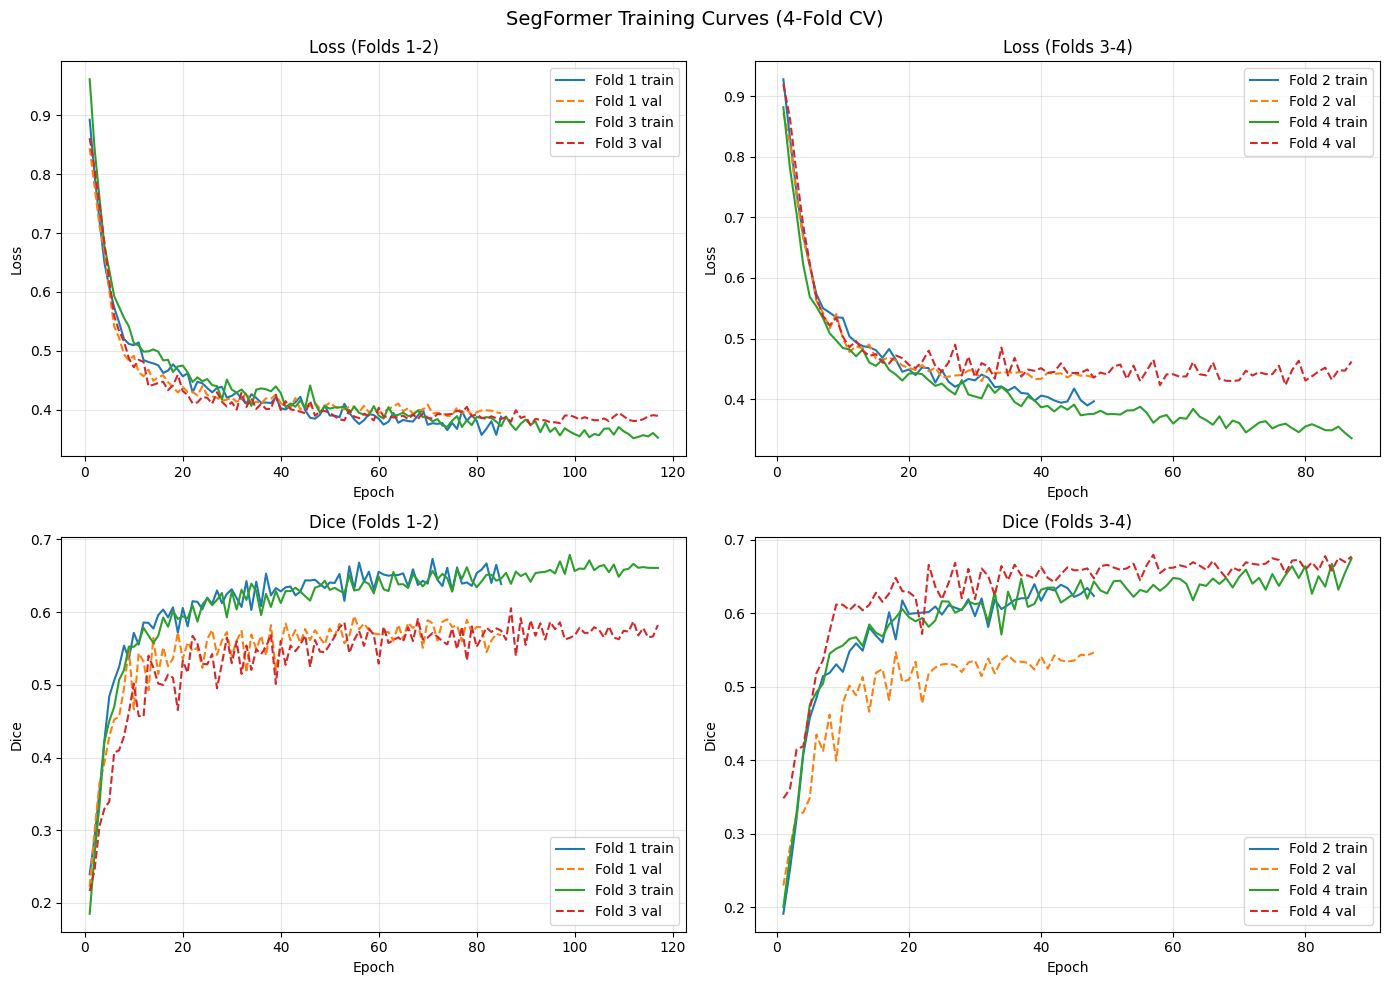

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for fold_idx, hist in enumerate(fold_histories):
    epochs = range(1, len(hist['train_loss']) + 1)
    
    axes[0, fold_idx % 2].plot(epochs, hist['train_loss'], label=f'Fold {fold_idx+1} train')
    axes[0, fold_idx % 2].plot(epochs, hist['val_loss'], '--', label=f'Fold {fold_idx+1} val')
    axes[1, fold_idx % 2].plot(epochs, hist['train_dice'], label=f'Fold {fold_idx+1} train')
    axes[1, fold_idx % 2].plot(epochs, hist['val_dice'], '--', label=f'Fold {fold_idx+1} val')

for i in range(2):
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].set_title(f'Loss (Folds {2*i+1}-{2*i+2})')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('Dice')
    axes[1, i].set_title(f'Dice (Folds {2*i+1}-{2*i+2})')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('SegFormer Training Curves (4-Fold CV)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Per-Image Evaluation

各foldのbest modelで対応するvalidation画像を推論し、per-imageメトリクスを計算

In [11]:
def compute_full_metrics(pred_binary, gt_binary, circle_mask):
    """circle_mask内でDice, IoU, Sensitivity, Specificity, Precisionを計算。"""
    valid = circle_mask > 0
    p = pred_binary[valid] > 0
    g = gt_binary[valid] > 0
    
    tp = int(np.sum(p & g))
    fp = int(np.sum(p & ~g))
    fn = int(np.sum(~p & g))
    tn = int(np.sum(~p & ~g))
    
    dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    return {'dice': dice, 'iou': iou, 'sensitivity': sens, 'specificity': spec, 'precision': prec}


@torch.no_grad()
def predict_image(model, img_path, device):
    """Single image prediction at 512x512."""
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    transform = get_val_transform()
    transformed = transform(image=img_rgb)
    img_tensor = transformed['image'].unsqueeze(0).to(device)
    
    model.eval()
    logits = model(img_tensor)
    pred = (torch.sigmoid(logits) > 0.5).squeeze().cpu().numpy().astype(np.uint8)
    return pred


# Evaluate all images using their respective fold models
per_image_results = []
all_predictions = {}  # stem -> pred_mask
erode_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * EVAL_ERODE_PX + 1, 2 * EVAL_ERODE_PX + 1))

for fold_info in fold_results:
    fold = fold_info['fold']
    val_idx = fold_info['val_indices']
    
    # Load best model for this fold
    model = SegFormerBinary('nvidia/mit-b3').to(device)
    model.load_state_dict(torch.load(OUTPUT_DIR / f'segformer_fold{fold}.pt', map_location=device, weights_only=True))
    
    for i in val_idx:
        stem = all_stems[i]
        pred = predict_image(model, all_img_paths[i], device)
        
        gt = cv2.imread(str(all_mask_paths[i]), cv2.IMREAD_GRAYSCALE)
        circle = cv2.imread(str(all_circle_paths[i]), cv2.IMREAD_GRAYSCALE)
        circle_eroded = cv2.erode(circle, erode_kernel, iterations=1)
        
        # Apply eroded circle mask to prediction
        pred[circle_eroded == 0] = 0
        
        metrics = compute_full_metrics(pred * 255, gt, circle_eroded)
        metrics['filename'] = stem
        metrics['fold'] = fold
        per_image_results.append(metrics)
        all_predictions[stem] = pred
    
    del model
    torch.cuda.empty_cache()

df_segformer = pd.DataFrame(per_image_results)
print('=== SegFormer Per-Image Metrics (eroded circle mask) ===')
print(df_segformer[['filename', 'fold', 'dice', 'iou', 'sensitivity', 'precision']].to_string(index=False))
print()
print('=== SegFormer Mean Metrics ===')
for col in ['dice', 'iou', 'sensitivity', 'specificity', 'precision']:
    print(f'  {col:>12s}: {df_segformer[col].mean():.3f} +/- {df_segformer[col].std():.3f}')

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b3 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b3 and are newly initialized: ['decode_head.batch_norm.bi

=== SegFormer Per-Image Metrics (eroded circle mask) ===
                            filename  fold     dice      iou  sensitivity  precision
0E900037-CE07-405C-82A4-5293EB2FC8F4     1 0.654836 0.486807     0.742667   0.585582
1C329021-715D-46B5-97AF-864952A86DF7     1 0.494244 0.328237     0.800361   0.357507
366E2260-EAA3-4CB5-BA99-690D5CDA75B2     1 0.719125 0.561433     0.844354   0.626245
6B193D74-82AE-4FAC-9DB2-D6DA4DBB56A6     1 0.678188 0.513075     0.818405   0.578990
83FA07F4-7781-4AFA-A51F-1A095E254CE7     1 0.703971 0.543175     0.890794   0.581925
94D75FAA-8AD0-4834-B089-16C71A57E182     1 0.374104 0.230091     0.337083   0.420260
286D9676-12C2-4026-A53D-73BD94502021     2 0.618690 0.447901     0.756439   0.523381
30A0F797-DEFD-4137-A11A-7E3529A7E0D4     2 0.004538 0.002274     0.002789   0.012158
7BA9B019-0851-427D-868A-EC84E1FC1C4C     2 0.737503 0.584162     0.829047   0.664166
7E4ADD96-1DFC-4B0D-84B8-F0A438327284     2 0.714270 0.555536     0.889960   0.596511
9CA1796B

## 8. Comparison: Frangi / U-Net / SegFormer

In [12]:
# Load Frangi and U-Net results
frangi_csv = DATA_DIR.parent / 'frangi_results.csv'
unet_csv = DATA_DIR.parent / 'unet_results.csv'

df_frangi = pd.read_csv(frangi_csv) if frangi_csv.exists() else None
df_unet = pd.read_csv(unet_csv) if unet_csv.exists() else None

print('=== 3-Method Comparison ===')
metrics_cols = ['dice', 'iou', 'sensitivity', 'specificity', 'precision']

header = f'{"Metric":>12s} |'
if df_frangi is not None:
    header += f' {"Frangi":>10s} |'
if df_unet is not None:
    header += f' {"U-Net":>10s} |'
header += f' {"SegFormer":>10s}'
print(header)
print('-' * len(header))

for col in metrics_cols:
    row = f'{col:>12s} |'
    if df_frangi is not None:
        row += f' {df_frangi[col].mean():>10.3f} |'
    if df_unet is not None:
        row += f' {df_unet[col].mean():>10.3f} |'
    row += f' {df_segformer[col].mean():>10.3f}'
    print(row)

# Per-image comparison (SegFormer vs U-Net)
if df_unet is not None:
    print('\n=== Per-Image Dice: SegFormer vs U-Net ===')
    merged = df_segformer[['filename', 'dice']].merge(
        df_unet[['filename', 'dice']], on='filename', suffixes=('_segformer', '_unet')
    )
    merged['diff'] = merged['dice_segformer'] - merged['dice_unet']
    merged = merged.sort_values('diff', ascending=False)
    print(merged.to_string(index=False))
    
    n_better = (merged['diff'] > 0).sum()
    n_worse = (merged['diff'] < 0).sum()
    n_same = (merged['diff'] == 0).sum()
    print(f'\nSegFormer better: {n_better}, worse: {n_worse}, same: {n_same}')
    print(f'Mean diff: {merged["diff"].mean():+.3f}')

=== 3-Method Comparison ===
      Metric |     Frangi |      U-Net |  SegFormer
---------------------------------------------------
        dice |      0.337 |      0.621 |      0.609
         iou |      0.218 |      0.461 |      0.454
 sensitivity |      0.398 |      0.790 |      0.738
 specificity |      0.946 |      0.956 |      0.961
   precision |      0.314 |      0.518 |      0.526

=== Per-Image Dice: SegFormer vs U-Net ===
                            filename  dice_segformer  dice_unet      diff
A1D04A1C-700B-4401-9E72-861507FEE194        0.575707   0.529199  0.046508
DD8633C6-D3CF-4E7E-B532-C3FFBF96BC75        0.610302   0.582137  0.028165
83FA07F4-7781-4AFA-A51F-1A095E254CE7        0.703971   0.678279  0.025692
366E2260-EAA3-4CB5-BA99-690D5CDA75B2        0.719125   0.694386  0.024739
6FB55DC4-4899-43AA-B4DE-D10CB5DAC929        0.710615   0.686733  0.023882
0E900037-CE07-405C-82A4-5293EB2FC8F4        0.654836   0.636730  0.018106
B6257B84-4EA1-42D9-904A-0F0832CBC7AC        0.

## 9. Prediction Visualization

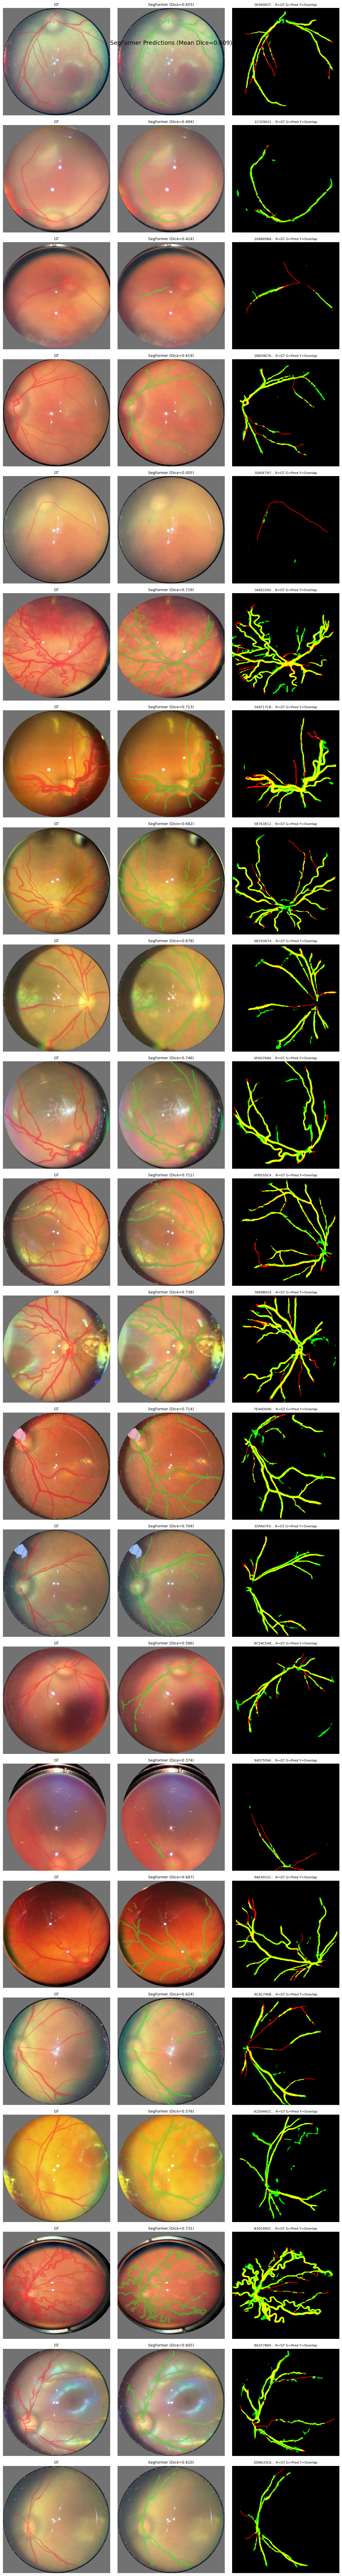

In [13]:
n = len(all_predictions)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1:
    axes = axes[np.newaxis, :]

for idx, stem in enumerate(sorted(all_predictions.keys())):
    img = cv2.imread(str(IMG_DIR / f'{stem}.png'))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt = cv2.imread(str(MASK_DIR / f'{stem}.png'), cv2.IMREAD_GRAYSCALE)
    pred = all_predictions[stem] * 255
    
    # GT overlay
    overlay_gt = img_rgb.copy()
    overlay_gt[gt > 0] = [255, 50, 50]
    blended_gt = cv2.addWeighted(img_rgb, 0.6, overlay_gt, 0.4, 0)
    axes[idx, 0].imshow(blended_gt)
    axes[idx, 0].set_title('GT', fontsize=9)
    axes[idx, 0].axis('off')
    
    # Prediction overlay
    overlay_pred = img_rgb.copy()
    overlay_pred[pred > 0] = [50, 255, 50]
    blended_pred = cv2.addWeighted(img_rgb, 0.6, overlay_pred, 0.4, 0)
    row_data = df_segformer[df_segformer['filename'] == stem]
    dice_val = row_data['dice'].values[0] if len(row_data) > 0 else 0
    axes[idx, 1].imshow(blended_pred)
    axes[idx, 1].set_title(f'SegFormer (Dice={dice_val:.3f})', fontsize=9)
    axes[idx, 1].axis('off')
    
    # Side-by-side masks
    combined = np.zeros((*gt.shape, 3), dtype=np.uint8)
    combined[:, :, 0] = gt  # Red = GT
    combined[:, :, 1] = pred  # Green = Pred
    # Yellow = overlap
    axes[idx, 2].imshow(combined)
    axes[idx, 2].set_title(f'{stem[:8]}... R=GT G=Pred Y=Overlap', fontsize=8)
    axes[idx, 2].axis('off')

plt.suptitle(f'SegFormer Predictions (Mean Dice={df_segformer["dice"].mean():.3f})', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Save SegFormer results
df_segformer.to_csv(DATA_DIR.parent / 'segformer_results.csv', index=False)
print(f'SegFormer results saved to {DATA_DIR.parent / "segformer_results.csv"}')

print(f'\n=== Final Summary ===')
if df_frangi is not None:
    print(f'Frangi    Mean Dice: {df_frangi["dice"].mean():.3f}')
if df_unet is not None:
    print(f'U-Net     Mean Dice: {df_unet["dice"].mean():.3f}')
print(f'SegFormer Mean Dice: {df_segformer["dice"].mean():.3f}')
if df_unet is not None:
    delta = df_segformer['dice'].mean() - df_unet['dice'].mean()
    sign = '+' if delta >= 0 else ''
    print(f'\nvs U-Net: {sign}{delta:.3f} Dice')

SegFormer results saved to C:\Users\ykita\ROP_AI_project\ROP_project\vascular_segmentation\segformer_results.csv

=== Final Summary ===
Frangi    Mean Dice: 0.337
U-Net     Mean Dice: 0.621
SegFormer Mean Dice: 0.609

vs U-Net: -0.012 Dice
